# 02 — Cleaning & EDA

**Goal:** clean the patched data (standardize categories, fix invalid values, cap outliers, filter to completed deliveries), then explore it visually.

Input: `data/order_delivery_patched.csv`
Output: `data/dataset_clean.csv` + charts in `reports/figures/`


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

INTERIM_PATH = Path("../data/order_delivery_patched.csv")
CLEAN_PATH = Path("../data/dataset_clean.csv")
FIGURES_DIR = Path("../reports/figures")

TARGET = "Delivery_Duration_Minutes"

In [2]:
df = pd.read_csv(INTERIM_PATH)
print(df.shape)
df.head()

(100002, 23)


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,16-06-2025 08:32,16-06-2025 09:11,31,Alexandria,Wallet,Delivered,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,03-06-2025 21:27,03-06-2025 22:00,8,Zagazig,Credit Card,Delivered,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,01-06-2025 14:48,01-06-2025 15:26,22,Assiut,Cash,In Transit,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,13-06-2025 02:30,13-06-2025 03:22,17,Mansoura,Cash,Delivered,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,06-06-2025 09:48,06-06-2025 10:32,8,Mansoura,Wallet,Delivered,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


## 2. Cleaning

This dataset was already structurally clean when we inspected it (no missing values, no duplicates). We still run defensive checks — the point is a pipeline that doesn't silently break if the data source ever changes — plus one real decision this dataset needs: standardizing text and filtering out orders that were never actually delivered.

### 2.1 Drop duplicates

In [3]:
before = len(df)
df = df.drop_duplicates().drop_duplicates(subset="Order_ID", keep="first")
print(f"Dropped {before - len(df)} duplicate rows")

Dropped 0 duplicate rows


### 2.2 Standardize categorical text

Strip whitespace and fix casing so `'low'`, `' Low'`, `'LOW'` aren't treated as three different categories. This dataset happens to be clean already, but this step protects against messier real-world data later.

In [4]:
cat_cols = ["Item_Name", "City", "Payment_Method", "Order_Status",
            "Driver_Vehicle", "Traffic_Level", "Driver_Availability"]
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

df[cat_cols].nunique()

Item_Name              9
City                   7
Payment_Method         3
Order_Status           3
Driver_Vehicle         3
Traffic_Level          3
Driver_Availability    2
dtype: int64

### 2.3 Null out logically-impossible values, then impute

Zero/negative price, quantity, or duration; negative distance; lat/lon outside Egypt's bounding box — these get set to NaN (not silently kept), then filled with the column median (numeric) or mode (categorical).

In [8]:
invalid_checks = {
    "Quantity": lambda s: s <= 0,
    "Total_Price": lambda s: s <= 0,
    "Delivery_Duration_Minutes": lambda s: s <= 0,
    "Delivery_Distance_km": lambda s: s < 0,
}
for col, cond in invalid_checks.items():
    bad = cond(df[col]).fillna(False)
    if bad.sum():
        df.loc[bad, col] = np.nan
        print(f"{col}: {bad.sum()} invalid values -> NaN")
    else:
        print(f'There are no Invalid Checks for {col}')    

print('='*40)

lat_cols = ["Restaurant_Lat", "Customer_Lat", "Driver_Lat"]
lon_cols = ["Restaurant_Lon", "Customer_Lon", "Driver_Lon"]
for col in lat_cols:
    bad = ~df[col].between(22, 32)
    if bad.sum():
        df.loc[bad, col] = np.nan
        print(f"{col}: {bad.sum()} out-of-range -> NaN")
    else:
        print(f'There are no Invalid Values for {col}')    

print('='*40)
        
for col in lon_cols:
    bad = ~df[col].between(25, 35)
    if bad.sum():
        df.loc[bad, col] = np.nan
        print(f"{col}: {bad.sum()} out-of-range -> NaN")
    else:
        print(f'There are no Invalid Values for {col}')    

There are no Invalid Checks for Quantity
There are no Invalid Checks for Total_Price
There are no Invalid Checks for Delivery_Duration_Minutes
There are no Invalid Checks for Delivery_Distance_km
There are no Invalid Values for Restaurant_Lat
There are no Invalid Values for Customer_Lat
There are no Invalid Values for Driver_Lat
There are no Invalid Values for Restaurant_Lon
There are no Invalid Values for Customer_Lon
There are no Invalid Values for Driver_Lon


In [9]:
num_cols = ["Total_Price", "Delivery_Distance_km", "Delivery_Duration_Minutes", "Quantity"] + lat_cols + lon_cols
for col in num_cols:
    n_missing = df[col].isna().sum()
    if n_missing:
        df[col] = df[col].fillna(df[col].median())
        print(f"{col}: {n_missing} missing -> median imputed")

for col in cat_cols:
    n_missing = df[col].isna().sum()
    if n_missing:
        df[col] = df[col].fillna(df[col].mode(dropna=True).iloc[0])
        print(f"{col}: {n_missing} missing -> mode imputed")

print("\nRemaining missing values:", df.isna().sum().sum())


Remaining missing values: 0


### 2.4 Cap outliers (winsorize)

We cap extreme values at the IQR fences rather than dropping rows — this preserves sample size while taming extreme leverage points that could distort a model later.

In [10]:
for col in ["Total_Price", "Delivery_Duration_Minutes", "Delivery_Distance_km", "Quantity"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_capped = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    if n_capped:
        print(f"{col}: {n_capped} outliers capped to [{lower:.2f}, {upper:.2f}]")

Delivery_Duration_Minutes: 2693 outliers capped to [-3.50, 40.50]
Delivery_Distance_km: 30 outliers capped to [-1.00, 5.28]


### 2.5 Filter to completed deliveries only

A `Cancelled` or `In Transit` order was never actually delivered — it has no real "delivery duration" in production, since you'd never know it at prediction time. We exclude these from the dataset we'll model on.

In [11]:
print(df['Order_Status'].value_counts())

before = len(df)
df_clean = df[df["Order_Status"] == "Delivered"].reset_index(drop=True)
print(f"\n{before} -> {len(df_clean)} rows ({before - len(df_clean)} Cancelled/In-Transit rows excluded)")

Order_Status
Delivered     85199
Cancelled      9812
In Transit     4991
Name: count, dtype: int64

100002 -> 85199 rows (14803 Cancelled/In-Transit rows excluded)


### 2.6 Fix wrong data types

The columns `Order_Time` & `Delivery_Time` need to be changed from **object** to **datetime** format and to use it to make useful analysis

In [14]:
for col in ['Order_Time', 'Delivery_Time']:
    df_clean[col] = pd.to_datetime(df_clean[col], dayfirst=True ,errors='coerce')

### 2.7 Final Checks on data

In [16]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85199 entries, 0 to 85198
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Order_ID                   85199 non-null  int64         
 1   User_ID                    85199 non-null  object        
 2   Restaurant_ID              85199 non-null  int64         
 3   Driver_ID                  85199 non-null  int64         
 4   Item_Name                  85199 non-null  object        
 5   Quantity                   85199 non-null  int64         
 6   Total_Price                85199 non-null  float64       
 7   Order_Time                 85199 non-null  datetime64[ns]
 8   Delivery_Time              85199 non-null  datetime64[ns]
 9   Delivery_Duration_Minutes  85199 non-null  float64       
 10  City                       85199 non-null  object        
 11  Payment_Method             85199 non-null  object        
 12  Orde

In [12]:
df_clean.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Order_ID,85199.0,49972.681557,28858.547016,1.000000,24991.500000,50002.000000,74965.500000,100002.000000
Restaurant_ID,85199.0,499.172655,288.507517,1.000000,249.000000,499.000000,749.000000,1000.000000
Driver_ID,85199.0,250.993005,144.245430,1.000000,126.000000,251.000000,376.000000,500.000000
Quantity,85199.0,2.989965,1.410209,1.000000,2.000000,3.000000,4.000000,5.000000
Total_Price,85199.0,268.989250,170.620376,30.000000,129.385000,233.430000,381.310000,750.000000
Delivery_Duration_Minutes,85199.0,19.401425,8.253135,8.000000,13.000000,18.000000,24.000000,40.500000
Restaurant_Lat,85199.0,30.117886,1.273073,27.160903,30.023077,30.587147,31.027120,31.220099
Restaurant_Lon,85199.0,31.062838,0.488512,29.898701,31.008897,31.209226,31.371863,31.521997
Customer_Lat,85199.0,30.117905,1.273078,27.160900,30.023244,30.586841,31.027181,31.220096
Customer_Lon,85199.0,31.062688,0.488554,29.898706,31.008471,31.208870,31.371857,31.521995


## 3. EDA (on the cleaned data)

### 3.1 Distributions

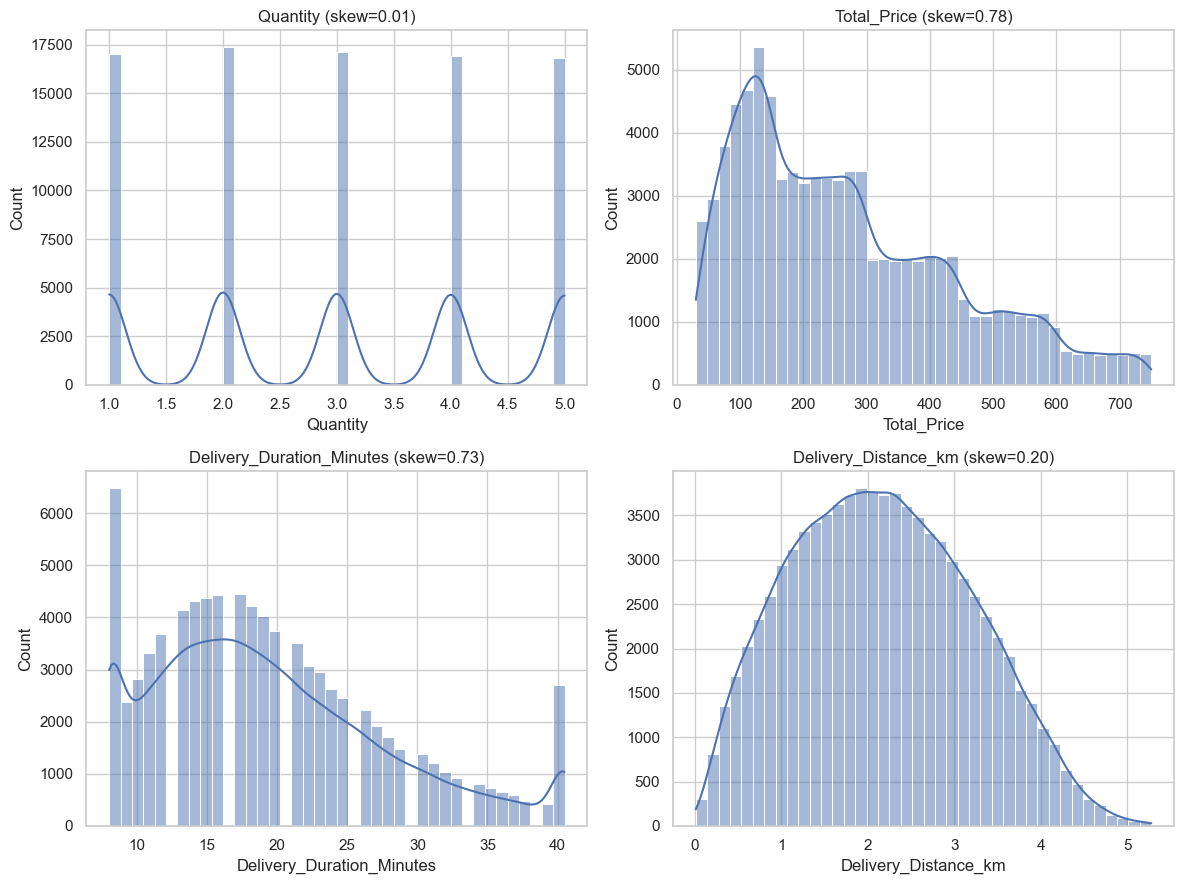

In [31]:
num_feats = ["Quantity", "Total_Price", TARGET, "Delivery_Distance_km"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flat, num_feats):
    sns.histplot(df_clean[col], kde=True, bins=40, ax=ax, color="#4C72B0")
    ax.set_title(f"{col} (skew={df_clean[col].skew():.2f})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_distributions.png", dpi=150)
plt.show()

### 3.2 Target vs. categorical features

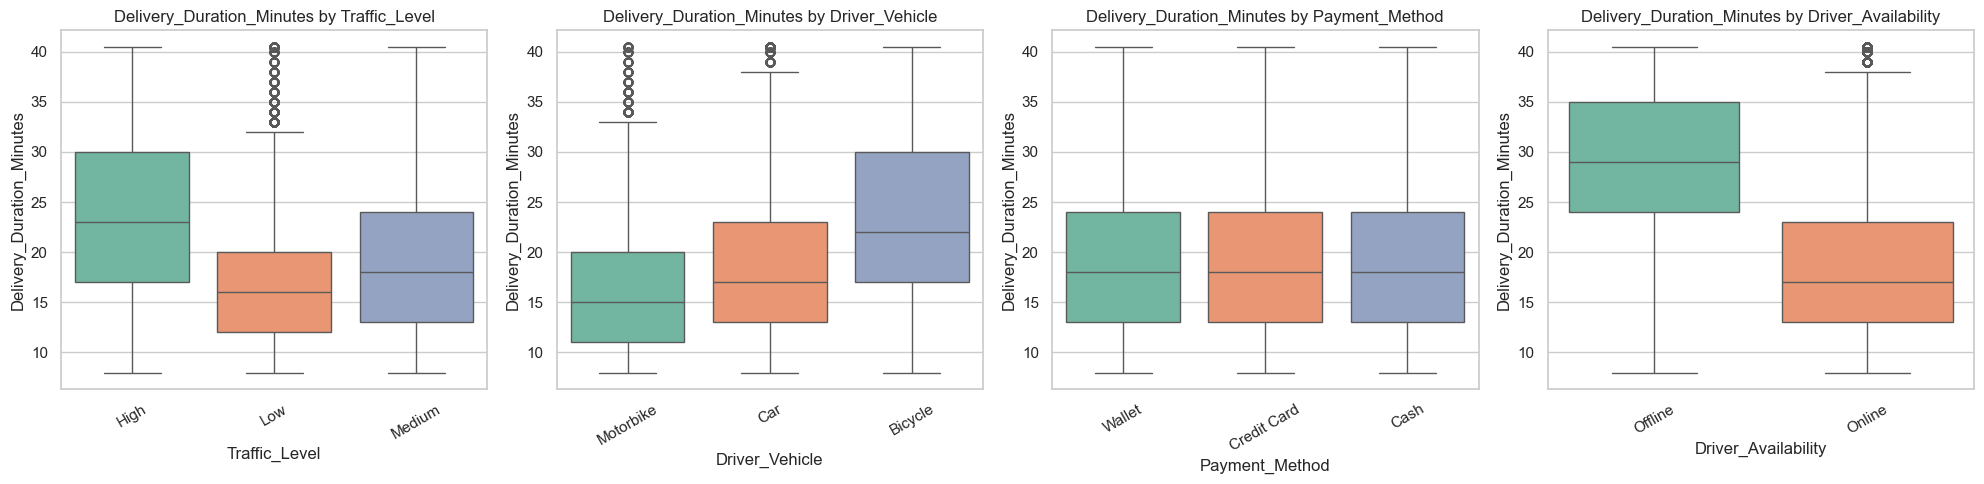

In [32]:
cat_feats = ["Traffic_Level", "Driver_Vehicle", "Payment_Method", "Driver_Availability"]
fig, axes = plt.subplots(1, len(cat_feats), figsize=(20, 5))
for ax, col in zip(axes, cat_feats):
    sns.boxplot(data=df_clean, x=col, y=TARGET, hue=col, palette="Set2", legend=False, ax=ax)
    ax.set_title(f"{TARGET} by {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_target_vs_categorical.png", dpi=150)
plt.show()

### 3.3 Categorical features Distributions

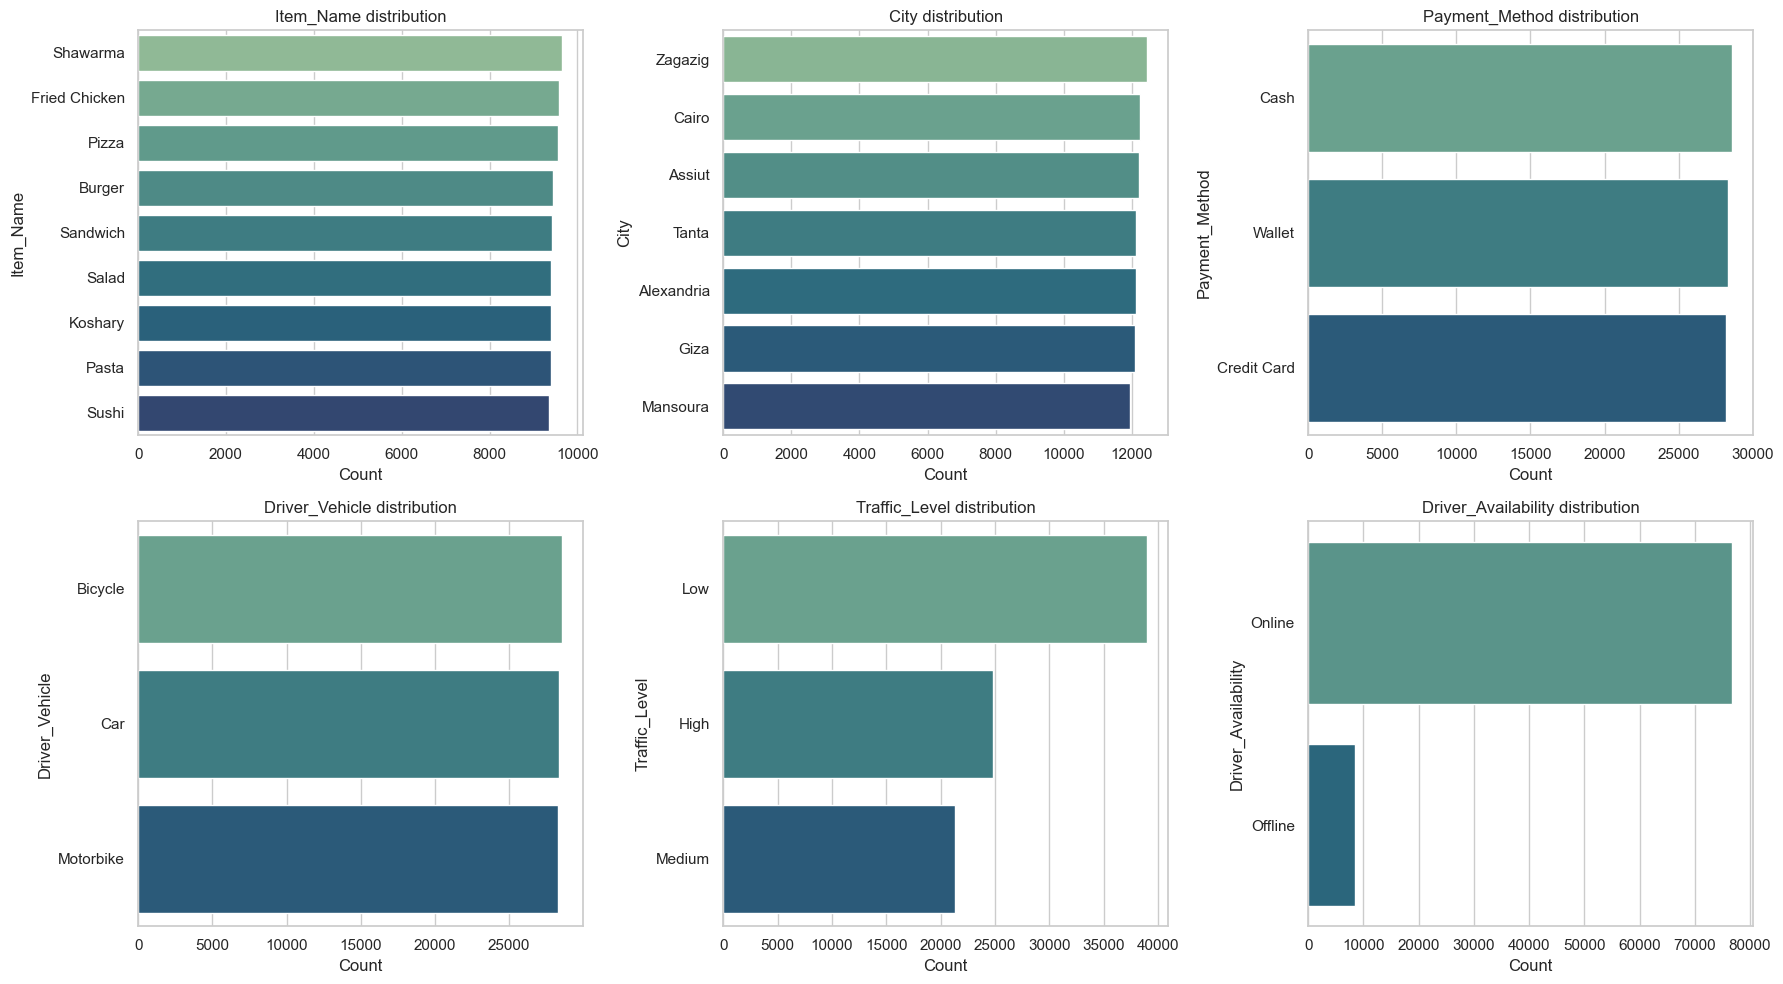

In [18]:
cat_to_plot = ["Item_Name", "City", "Payment_Method", "Driver_Vehicle",
               "Traffic_Level", "Driver_Availability"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, cat_to_plot):
    vc = df_clean[col].value_counts()
    sns.barplot(x=vc.values, y=vc.index, hue=vc.index, palette="crest", legend=False, ax=ax)
    ax.set_title(f"{col} distribution")
    ax.set_xlabel("Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_categorical_distributions.png", dpi=150)
plt.show()

### 3.4 Correlation heatmap

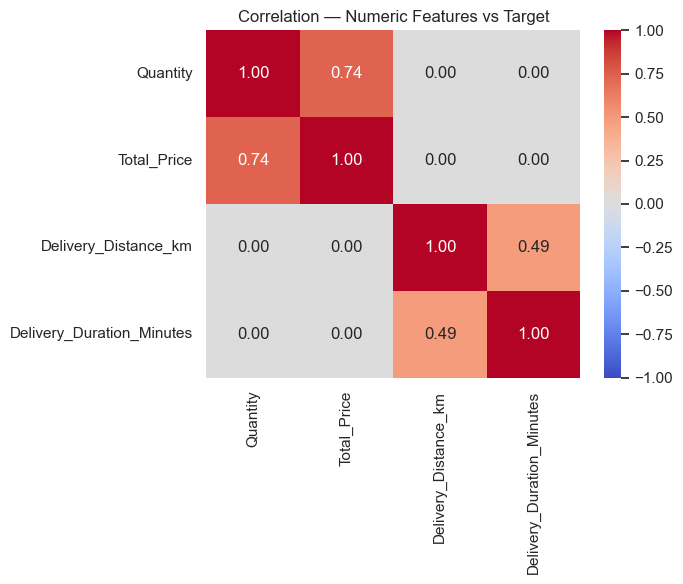

In [ ]:
corr_cols = ["Quantity", "Total_Price", "Delivery_Distance_km", TARGET]
plt.figure(figsize=(7, 6))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation — Numeric Features vs Target")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_correlation.png", dpi=150)
plt.show()

### 3.5 Order volume by hour & day of week

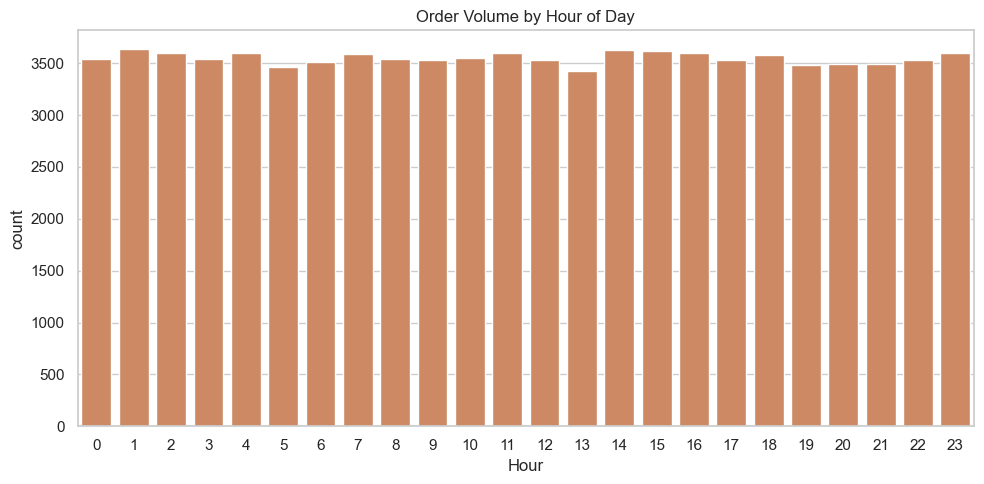

In [ ]:
order_hour = df_clean['Order_Time'].dt.hour
plt.figure(figsize=(10, 5))
sns.countplot(x=order_hour, color="#DD8452")
plt.title("Order Volume by Hour of Day")
plt.xlabel("Hour")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_orders_by_hour.png", dpi=150)
plt.show()

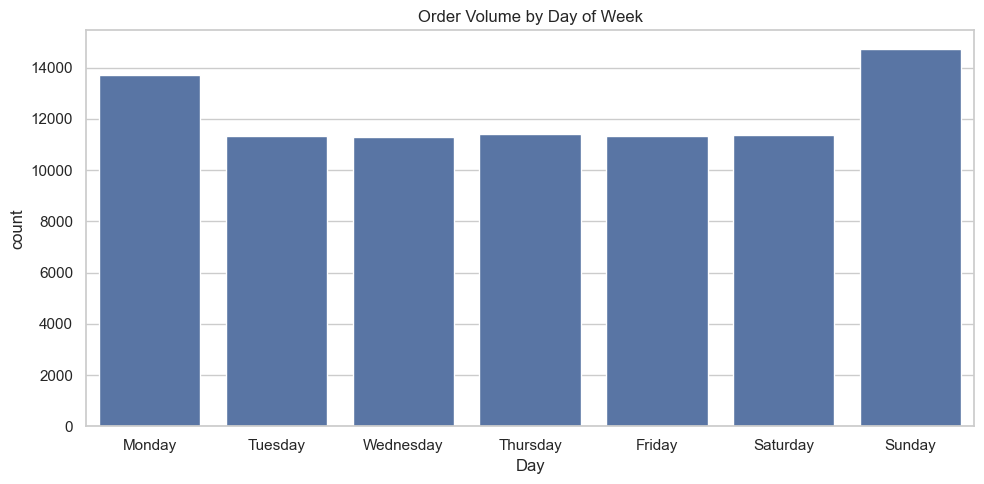

In [ ]:
order_dayofweek = df_clean['Order_Time'].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10, 5))
sns.countplot(x=order_dayofweek, order=day_order, color="#4C72B0")
plt.title("Order Volume by Day of Week")
plt.xlabel("Day")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_orders_by_day.png", dpi=150)
plt.show()

### 3.6 Cardinality check (matters for encoding later)

In [28]:
print(f'For a dataset whose length is {df_clean.shape[0]}:\n')
for c in ["Order_ID", "User_ID", "Restaurant_ID", "Driver_ID"]:
    print(f"{c}: {df_clean[c].nunique()} unique values")

For a dataset whose length is 85199:

Order_ID: 85199 unique values
User_ID: 9000 unique values
Restaurant_ID: 1000 unique values
Driver_ID: 500 unique values


## 4. Save cleaned data

In [29]:
df_clean.to_csv(CLEAN_PATH, index=False)
print(f"Saved -> {CLEAN_PATH}  shape={df_clean.shape}")

Saved -> ..\data\dataset_clean.csv  shape=(85199, 23)
